# **TASK 2**: Find The Most Influential Node Combination
### Imports

In [1]:
import time
from tqdm import tqdm
import random
import networkx as nx
import numpy as np
import pandas as pd

In [2]:
# load the graph
# The graph is an extraction from LinkedIn Social Network
G = nx.read_gexf("mediumLinkedin.gexf")

### General infos

In [3]:
#df_e_partial = pd.read_csv('employer_with_60percent_of_nodes_remoded.csv', sep='\t', header='infer')
#df_c_partial = pd.read_csv('college_with_60percent_of_nodes_remoded.csv', sep='\t', header='infer')
df_l_partial = pd.read_csv('location_with_60percent_of_nodes_remoded.csv', sep='\t', header='infer')
#df_e_truth = pd.read_csv('./groundtruth/employer.csv', sep='\t', header='infer')
#df_c_truth = pd.read_csv('./groundtruth/college.csv', sep='\t', header='infer')
df_l_truth = pd.read_csv('./groundtruth/location.csv', sep='\t', header='infer')

df_l_pred = pd.read_csv('pred.csv', sep=',', header='infer')

In [4]:
target_location = "san francisco bay area"
working_df = df_l_pred

P_SHARE = 0.1
best_influencers_algo = "greedy" # "greedy", "tabu", "both", or manual

In [5]:
target_nodes = set(list(working_df[working_df["location"] == target_location]["name"]))
target_nodes_truth = set(list(df_l_truth[df_l_truth["location"] == target_location]["name"]))
target_nodes_partial = set(list(df_l_partial[df_l_partial["location"] == target_location]["name"]))

print(f"Number of predicted target nodes : {len(target_nodes)}")

Number of predicted target nodes : 152


### Data Exploration

In [6]:
# Now we count for each node, how many nodes to influence are of distance 1, 2 and 3
def analyse_close_circle(max_depth, weights=None):
    if weights is None:
        weights = [1, 0.25, 0.06]
        
    relations_list = {}
    interest_score = {}
    
    for node in G.nodes():
        distances = nx.single_source_shortest_path_length(G, node, cutoff=max_depth)
        
        influencees_list = [[]] * max_depth
        
        for target_node, dist in distances.items():
            if 0 < dist <= max_depth and target_node in target_nodes:
                influencees_list[dist - 1].append(target_node)
                
        relations_list[node] = influencees_list    
        interest_score[node] = sum([len(influencees_list[i]) * weights[i] for i in range(max_depth)])
        
    interest_score = sorted(interest_score.items(), key=lambda item: item[1], reverse=True)

    return influencees_list, interest_score

In [7]:
#analyse_close_circle(3)

### Main logic

In [8]:
# Simulation Functions

#stats_convergence = []

def run_simulation(source_nodes, p_share=P_SHARE, max_iter=50, tol=1e-5, verbose=False):
    """Runs a simulation of the influence of posts made by source_nodes. Returns a DataFrame of each node's share_likelihood"""
    if verbose:
        print("Started simulation, with source nodes :", source_nodes)
        start_time = time.time()
        
    #stats_to_remember = []
    
    # Initialisation
    nodes = list(G.nodes())
    n = len(nodes)
    node_idx = {node: i for i, node in enumerate(nodes)}
    
    # P_current : Probability to share at instant t
    P_current = np.zeros(n)
    for node in source_nodes:
        P_current[node_idx[node]] = 1.0
        
    P_initial = P_current.copy()
    
    for iteration in range(max_iter):
        P_next = np.zeros(n)
        
        for i, node in enumerate(nodes):
            if P_initial[i] == 1.0:
                P_next[i] = 1.0
                continue
                
            # Probability of NOT sharing
            prob_not_share = 1.0
            for neighbor in G.neighbors(node):
                j = node_idx[neighbor]
                prob_not_share *= (1 - p_share * P_current[j])
                
            P_next[i] = 1 - prob_not_share
            
        # Convergence check (quite rare)
        if  np.max(np.abs(P_next - P_current))< tol:
            break
            
        P_current = P_next
    
    if verbose:
        print(f"/t Finished simulation, elapsed time {time.time() - start_time}")
        
    #stats_convergence.append(stats_to_remember)
        
    return pd.DataFrame(zip(nodes, P_current), columns=["name", "score"]).set_index('name')


In [9]:
# Metrics
def compute_influence_score(source_nodes, true_target_nodes=False, **kwargs):
    """Computes the *influence_score*, or share of target users that are reached by a post"""
    if true_target_nodes:
        target_nodes_choice = target_nodes_truth
    else:
        target_nodes_choice = target_nodes
        
    share_probs = run_simulation(source_nodes=source_nodes, **kwargs)['score']
    
    total_influence = 0
    
    for node in target_nodes_choice:
        neighbors = list(G.neighbors(node))
        
        probs_neighbors = share_probs.reindex(neighbors).fillna(0)
        prob_not_seen = (1 - probs_neighbors).prod()
            
        total_influence += (1 - prob_not_seen)
    
    return total_influence / len(target_nodes)

In [10]:
# Greedy search
def best_influencers_greedy(**kwargs):
    selected_nodes = []
    
    for i in tqdm(range(5), unit="Step"):
        best_current_node = None
        best_current_score = -1
        
        for node in G.nodes():
            if node in selected_nodes:
                continue
            
            # Tests current combination + candidate node
            test_selection = selected_nodes + [node]
            current_score = compute_influence_score(test_selection, **kwargs)
            
            if current_score > best_current_score:
                best_current_score = current_score
                best_current_node = node
        
        if best_current_node:
            selected_nodes.append(best_current_node)
            print(f"Node {i+1} sélectionné : {best_current_node} (Score: {best_current_score:2f})")
            
    return selected_nodes, best_current_score

In [11]:
# Tabu search
def best_influencers_tabu(current_selection = None, iterations=100, n_candidates_per_it=40, n_nodes=5, **kwargs):
    # Initialisation
    if current_selection is None:
        current_selection = random.sample(list(G.nodes()), n_nodes)
    best_selection = list(current_selection)
    best_score = compute_influence_score(best_selection, **kwargs)
    
    tabu_list = set()
    tabu_history = []
    max_tabu_size = 15
    
    pbar = tqdm(range(iterations))
    for _ in pbar:
        candidate_selection = None
        candidate_score = -1
        node_to_block = None

        # Candidates sample
        sampled_candidates = random.sample(list(G.nodes()), n_candidates_per_it) 
        
        for i in range(5):
            old_node = current_selection[i]
            for new_node in sampled_candidates:
                if new_node in current_selection or new_node in tabu_list:
                    continue
                
                test_selection = list(current_selection)
                test_selection[i] = new_node
                
                current_test_score = compute_influence_score(test_selection, **kwargs)
    
                # If its better, keep in memory
                if current_test_score > candidate_score:
                    candidate_score = current_test_score
                    candidate_selection = test_selection
                    node_to_block = old_node

        if candidate_selection:
            current_selection = candidate_selection
            
            if candidate_score > best_score:
                best_score = candidate_score
                best_selection = list(candidate_selection)
            
            # Tabu memory
            if node_to_block not in tabu_list:
                tabu_list.add(node_to_block)
                tabu_history.append(node_to_block)
                
            if len(tabu_history) > max_tabu_size:
                to_remove = tabu_history.pop(0)
                tabu_list.remove(to_remove)

    return best_selection, best_score

In [12]:
# Run influencer selection
start_time = time.time()

if best_influencers_algo == "greedy":
    best_selection, best_score = best_influencers_greedy(
        p_share=P_SHARE
    )
    
    print(f"Final selection : {best_selection}")
    print(f"Final score : {best_score:2f}")
    
elif best_influencers_algo == "tabu":
    best_selection, best_score = best_influencers_tabu(
        current_selection=['U7024', 'U3955', 'U2691', 'U22747', 'U11566'],
        n_candidates_per_it=25,
        p_share=P_SHARE
    )
    
    print(f"Final selection : {best_selection}")
    print(f"Final score : {best_score:2f}")    
    
elif best_influencers_algo == "both":
    best_selection_greedy, best_score_greedy = best_influencers_greedy(
        p_share=P_SHARE
    )
    
    print(f"Greedy first selection : {best_selection_greedy}")
    print(f"Greedy first score : {best_score_greedy:2f}")
    
    best_selection, best_score = best_influencers_tabu(
        current_selection=best_selection_greedy,
        n_candidates_per_it=25,
        p_share=P_SHARE
    )
    print(f"Final selection : {best_selection}")
    print(f"Final score : {best_score:2f}")
    
else:
    best_selection = ['U7024', 'U27287', 'U3955', 'U22747', 'U16141']
    
print(f"Elapsed time : {time.time() - start_time}")

# with pred (v1) ['U7024', 'U3955', 'U2691', 'U22747', 'U11566']
# with pred (v2) ['U7024', 'U27287', 'U3955', 'U22747', 'U16141']

 20%|██        | 1/5 [00:38<02:32, 38.08s/Step]

Node 1 sélectionné : U7024 (Score: 0.730839)


 40%|████      | 2/5 [01:16<01:54, 38.28s/Step]

Node 2 sélectionné : U22747 (Score: 0.829437)


 60%|██████    | 3/5 [01:54<01:16, 38.36s/Step]

Node 3 sélectionné : U27287 (Score: 0.881939)


 80%|████████  | 4/5 [02:32<00:37, 37.90s/Step]

Node 4 sélectionné : U16141 (Score: 0.907886)


100%|██████████| 5/5 [03:09<00:00, 37.84s/Step]

Node 5 sélectionné : U3955 (Score: 0.924590)
Final selection : ['U7024', 'U22747', 'U27287', 'U16141', 'U3955']
Final score : 0.924590
Elapsed time : 189.2076599597931


In [13]:
print(compute_influence_score(['U7024', 'U22747', 'U27287', 'U16141', 'U3955'], true_target_nodes=True))
print(compute_influence_score(['U7024', 'U22747', 'U27287', 'U16141', 'U3955'], true_target_nodes=False))

0.3656939699259439
0.9245895957927573


### Result visualisation

In [14]:
# Graph influence_score over p_share
if False:
    plt.close('all')
    
    # Simulations
    probabilities = np.logspace(np.log10(0.01), np.log10(1), num=30)
    mean_scores = []
    for p in tqdm(probabilities):
        all_scores = []
        
        for user in G.nodes():
            res = run_simulation([user], verbose=False, p_share=p)
            all_scores.append(compute_influence_score(res))
            
        mean_scores.append(np.mean(all_scores))
    
    # Plot
    plt.figure(figsize=(10, 6))
    plt.plot(probabilities, mean_scores, marker='o', linestyle='-', color='#2c3e50', markersize=4)
    
    plt.xscale('log')
    
    plt.title("Influence_score function of SHARE_PROBABILITY")
    plt.xlabel("SHARE_PROBABILITY - Log Scale")
    plt.ylabel("influence_score")
    
    plt.grid(True, which="both", ls="-", alpha=0.5)
    plt.legend()
    
    plt.show()

In [15]:
import networkx as nx
import matplotlib.pyplot as plt

def visualize_influence(selected_influencers, figsize=(12, 5), zoom=False, zoom_radius=0.2, only_show_target_nodes=True, true_target_nodes=False, **kwargs):
    if true_target_nodes:
        target_nodes_choice = target_nodes_truth
        subtitle = "True target nodes"
    else:
        target_nodes_choice = target_nodes
        subtitle = "Predicted target nodes"

    influence_scores = run_simulation(selected_influencers, **kwargs)
    
    fig, ax = plt.subplots(figsize=figsize, facecolor='white')
    
    pos = nx.spring_layout(G, k=0.5, iterations=100, seed=42)
    
    # Drawing the edges
    nx.draw_networkx_edges(G, pos, ax=ax, alpha=0.1, width=0.4, edge_color='gray')
    
    # Other nodes (we dont care much about them)
    if only_show_target_nodes:
        other_nodes = [node for node in G.nodes() if (node not in selected_influencers) and (node not in target_nodes_choice)]
        
        nx.draw_networkx_nodes(G, pos, ax=ax,
                               nodelist=other_nodes, 
                               node_size=15, 
                               node_color='gray',
                               alpha=0.25,
                               edgecolors='#bcbcbc', 
                               linewidths=0.8,
                               label="Other nodes")
    
    # Target Nodes
    if only_show_target_nodes:
        influenced_nodes = [node for node in target_nodes_choice if node not in selected_influencers]
    else:
        influenced_nodes = [node for node in G.nodes() if node not in selected_influencers]

    couleurs_cibles = [influence_scores.at[node, "score"] for node in influenced_nodes]
    
    nodes_cibles = nx.draw_networkx_nodes(G, pos, ax=ax,
                                          nodelist=influenced_nodes, 
                                          node_size=50, 
                                          node_color=couleurs_cibles,
                                          cmap=plt.cm.PuBu,
                                          edgecolors='#bcbcbc',
                                          linewidths=0.8,
                                          label="Target Nodes")
    
    # Influencer nodes
    nx.draw_networkx_nodes(G, pos, ax=ax,
                           nodelist=selected_influencers, 
                           node_size=250, 
                           node_color='#2F4F4F', 
                           node_shape='s', 
                           edgecolors='black', 
                           linewidths=2,
                           label="Influencer")

    # Write the influencers labels on the graph
    labels = {n: n for n in selected_influencers}
    nx.draw_networkx_labels(G, pos, labels=labels, ax=ax, font_size=8, font_weight='bold')

    # Zoom logic
    if zoom and selected_influencers:
        inf_node = selected_influencers[0]
        x, y = pos[inf_node]
        ax.set_xlim(x - zoom_radius, x + zoom_radius)
        ax.set_ylim(y - zoom_radius, y + zoom_radius)
        title_prefix = "ZOOM View"
    else:
        # Force plt to show the whole graph (had bugs with constant zoom)
        all_pos = list(pos.values())
        x_values = [p[0] for p in all_pos]
        y_values = [p[1] for p in all_pos]
        
        margin = 0.05
        ax.set_xlim(min(x_values) - margin, max(x_values) + margin)
        ax.set_ylim(min(y_values) - margin, max(y_values) + margin)
        title_prefix = "Global View"
        
    
    # Legend
    ax.set_title(f"{title_prefix} - Influencer{'s' if len(selected_influencers) > 1 else ''}: {selected_influencers}\n{subtitle}", fontsize=15)
    ax.axis('off') 
    
    plt.colorbar(nodes_cibles, ax=ax, shrink=0.4)
    plt.show()


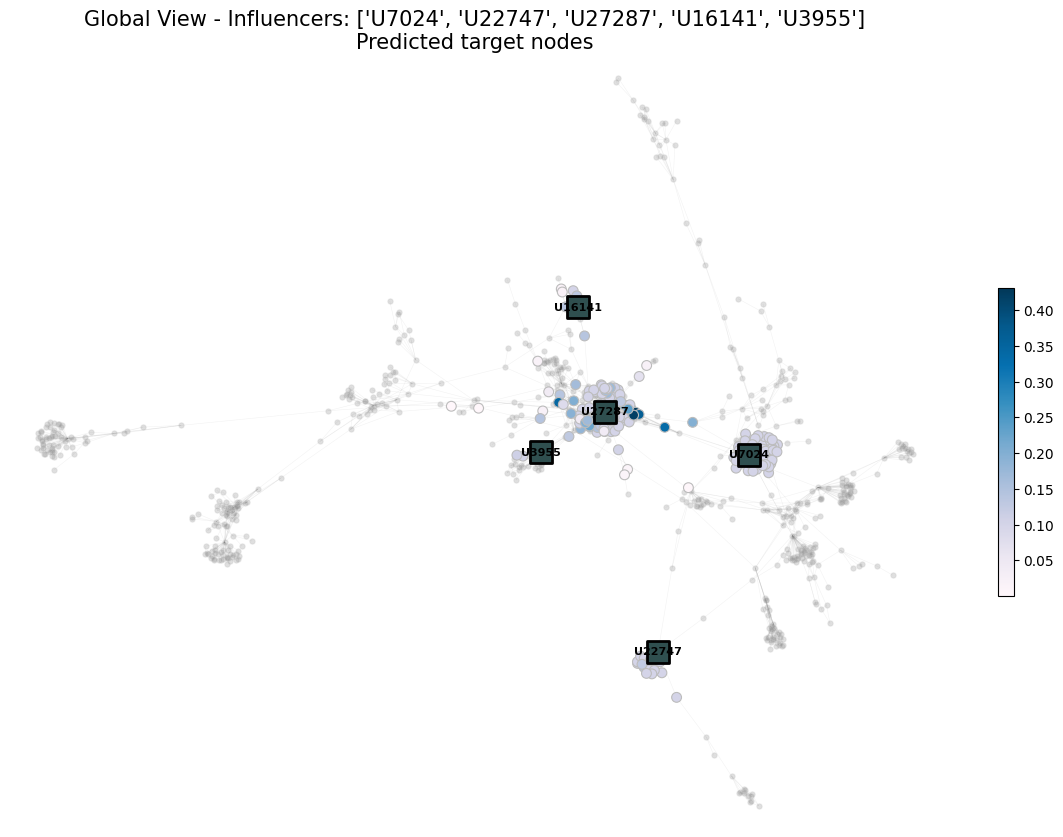

In [16]:
visualize_influence(
    selected_influencers=best_selection, 
    figsize=(15, 10),
    p_share=P_SHARE,
    zoom=False,
    true_target_nodes=False
)

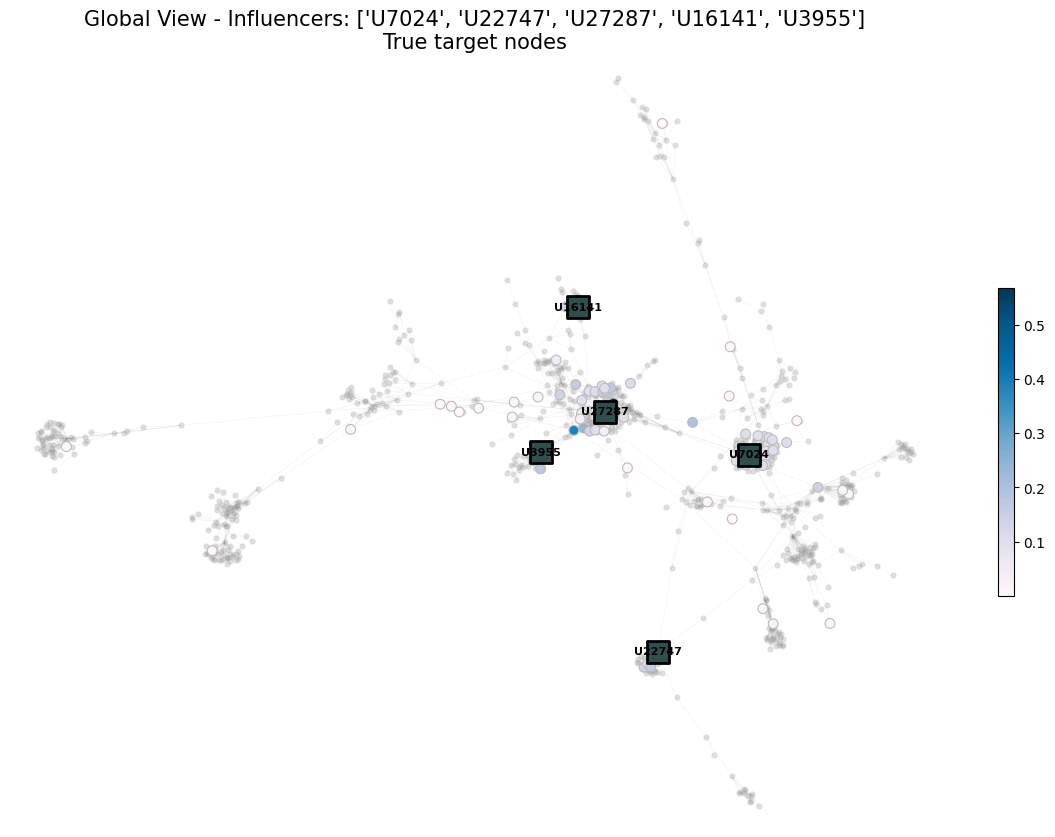

In [17]:
visualize_influence(
    selected_influencers=best_selection, 
    figsize=(15, 10),
    p_share=P_SHARE,
    zoom=False,
    true_target_nodes=True
)